An example where you don't use the CLI and use the defined classes directly

In [15]:
import sys
import os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Add the parent directory to the path so we can import the main app modules
sys.path.append(os.path.abspath('..'))

from metamer_finder import MetamerOptimizer, FeatureExtractor


In [18]:
# 1. Define a dummy BCI model (e.g., predicting 2D kinematics from spikes)
class DummyDecoder(nn.Module):
    def __init__(self, num_neurons=50, hidden_size=64):
        super().__init__()
        # Input shape: (Batch, Neurons, Time)
        self.conv1d = nn.Conv1d(in_channels=num_neurons, out_channels=hidden_size, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.fc = nn.Linear(hidden_size, 2) # Output X/Y velocity

    def forward(self, x):
        x = self.conv1d(x)
        x = self.relu(x)
        # Global average pooling over time
        x = torch.mean(x, dim=2)
        return self.fc(x)

model = DummyDecoder().eval()

# 2. Wrap it in your FeatureExtractor. 
# We will target the output of the 'relu' layer
extractor = FeatureExtractor(model, target_layers=["relu"])

In [19]:
# 1. Generate a fake "target" spike train: Batch=1, Neurons=50, TimeBins=100
# We use requires_grad=False because this is the ground-truth we want to match
target_spike_train = torch.rand(1, 50, 100)

# 2. Extract the target activations we want the optimizer to match
with torch.no_grad():
    target_features = extractor(target_spike_train)

# 3. Define our biological constraint (L1 Sparsity)
def biological_sparsity_loss(tensor, current_features, target_features):
    """Penalizes dense firing, forcing the optimizer to use fewer spikes."""
    return torch.sum(torch.abs(tensor)) * 0.005

In [20]:
# Initialize your data-agnostic engine
optimizer = MetamerOptimizer(
    extractor=extractor,
    target_features=target_features,
    lr=0.01,
    max_iterations=300,
    tv_weight=0.0, # TV loss makes no sense for discrete spikes
    loss_type="mse",
    custom_loss_hook=biological_sparsity_loss
)

# Create a random noise tensor of the exact same shape to start the optimization
starting_noise = torch.rand(1, 50, 100)

print("Optimizing neural metamer...")
# Run the generate function (this matches the updated loop you pasted earlier)
optimized_neural_metamer = optimizer.generate(starting_image=starting_noise)
print("Optimization Complete!")

Optimizing neural metamer...


Optimizing (mse): 100%|██████████| 300/300 [00:00<00:00, 339.51it/s, loss=0.064119]

Optimization Complete!


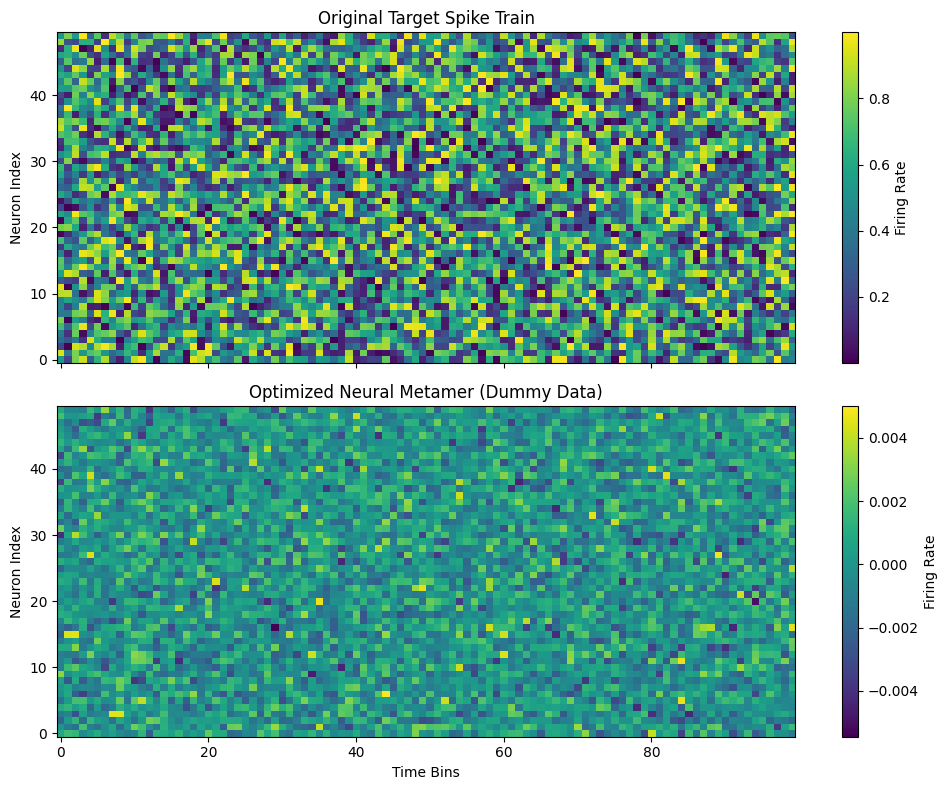

In [24]:
# Extract the 2D matrices (Neurons x TimeBins) for visualization
# Make sure to grab the target_spike_train from Cell 3!
target_matrix = target_spike_train[0].detach().cpu().numpy()
metamer_matrix = optimized_neural_metamer[0].detach().cpu().numpy()

# Create a vertically stacked plot sharing the same X and Y axes
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 8), sharex=True, sharey=True)

vmin = min(target_matrix.min(), metamer_matrix.min())
vmax = max(target_matrix.max(), metamer_matrix.max())
# Then pass vmin=vmin, vmax=vmax into both imshow() calls!

# 1. Plot the Original Target Data
im1 = axes[0].imshow(target_matrix, aspect='auto', cmap='viridis', origin='lower')
axes[0].set_title("Original Target Spike Train")
axes[0].set_ylabel("Neuron Index")
fig.colorbar(im1, ax=axes[0], label="Firing Rate")

# 2. Plot the Optimized Metamer
im2 = axes[1].imshow(metamer_matrix, aspect='auto', cmap='viridis', origin='lower')
axes[1].set_title("Optimized Neural Metamer (Dummy Data)")
axes[1].set_xlabel("Time Bins")
axes[1].set_ylabel("Neuron Index")
fig.colorbar(im2, ax=axes[1], label="Firing Rate")
vmin = min(target_matrix.min(), metamer_matrix.min())
vmax = max(target_matrix.max(), metamer_matrix.max())
# Then pass vmin=vmin, vmax=vmax into both imshow() calls!
plt.tight_layout()
plt.show()